In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from somJ.som import SoM
from functions import load_dataset
import somJ.config as config
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

2025-05-26 19:08:43.328365: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-26 19:08:43.328912: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-26 19:08:43.331618: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-26 19:08:43.338498: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748282923.349895 2393712 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748282923.35

In [2]:
# Parámetros generales
samples = [1, 5, 10, 25, 50, 75, 100, 150, 200]
datasets = ['Iris', 'Digits', 'MNIST', 'Fashion MNIST']
total_nodes = config.TOTAL_NODES
n_splits = 5

# Directorio de salida
out_dir = 'g_label'
os.makedirs(out_dir, exist_ok=True)

# Aquí guardaremos las medias y desviaciones
results_mean = {}
results_std  = {}

for ds in datasets:
    print(f"\n=== Procesando {ds} con 5-fold ===")
    X, y = load_dataset(ds)
    
    # Prepara estructuras de resultados
    acc_folds = {s: [] for s in samples}
    
    # StratifiedKFold para clasificación
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Recorremos los pliegues
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        print(f"  Fold {fold_idx}/{n_splits}")
        X_train, y_train = X[train_idx], y[train_idx]
        X_test,  y_test  = X[test_idx],  y[test_idx]
        
        # Entrenamos el SOM con todo el train
        som = SoM(
            method="pca",
            data=X_train,
            total_nodes=total_nodes
        )
        som.train(
            train_data=X_train,
            learn_rate=config.LEARNING_RATE,
            epochs=1,            
            update="online",
            prog_bar=False
        )
        
        # Representaciones SOM de todo el train
        X_som_train = np.array(som.find_all_winner(X_train))
        
        # Para cada tamaño de etiquetado, entrenamos y evaluamos
        for s in samples:
            cutoff = s
            X_lab = X_som_train[:cutoff]
            y_lab = y_train[:cutoff]
            
            y_pred = som.predict(X_lab, y_lab, X_test)
            acc = accuracy_score(y_test, y_pred)
            acc_folds[s].append(acc)
    
    # Calculamos media y desviación para cada s
    means = []
    stds  = []
    for s in samples:
        arr = np.array(acc_folds[s])
        means.append(arr.mean())
        stds.append(arr.std(ddof=1))  # ddof=1 para muestra
        print(f"  Muestras={s:3d} → mean={arr.mean():.3f}, std={arr.std(ddof=1):.3f}")
    
    results_mean[ds] = means
    results_std[ds]  = stds


=== Procesando Iris con 5-fold ===
  Fold 1/5


    Prediciendo:   0%|                                   | 0/30 [00:00<?, ?it/s]


  Fold 2/5


    Prediciendo:   0%|                                   | 0/30 [00:00<?, ?it/s]


  Fold 3/5


...

  Fold 4/5


    Prediciendo:   0%|                                | 0/12000 [00:00<?, ?it/s]


  Fold 5/5


    Prediciendo:   0%|                                | 0/12000 [00:00<?, ?it/s]

  Muestras=  1 → mean=0.100, std=0.000
  Muestras=  5 → mean=0.221, std=0.064
  Muestras= 10 → mean=0.348, std=0.034
  Muestras= 25 → mean=0.492, std=0.051
  Muestras= 50 → mean=0.547, std=0.019
  Muestras= 75 → mean=0.577, std=0.031
  Muestras=100 → mean=0.615, std=0.022
  Muestras=150 → mean=0.631, std=0.022
  Muestras=200 → mean=0.648, std=0.014


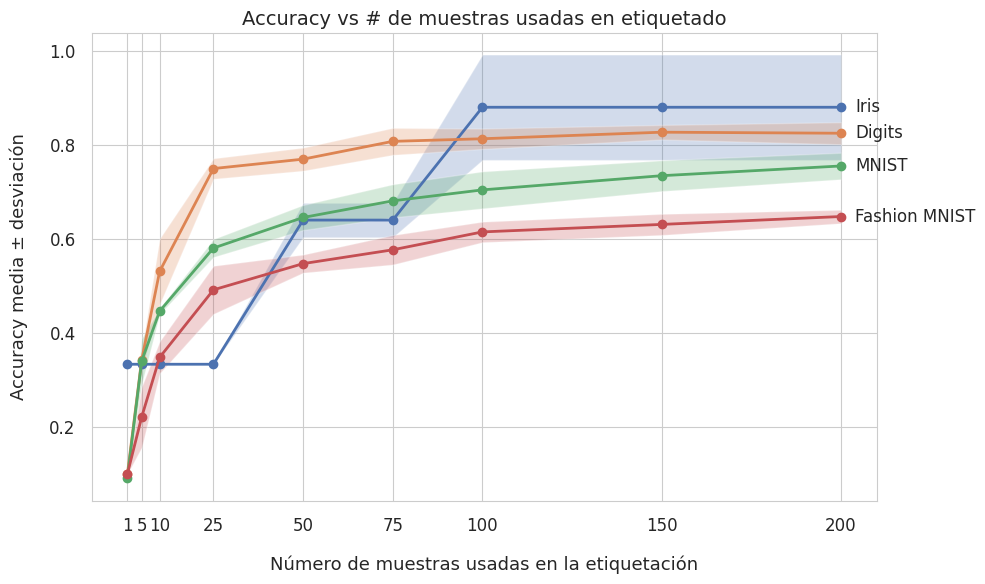

In [ ]:
# Estilo y paleta
sns.set_style('whitegrid')
sns.set_palette('deep')
plt.rc('font', size=12)
plt.rc('axes', titlesize=14, labelsize=13)
plt.rc('legend', fontsize=12)

# Creamos figura y ejes
fig, ax = plt.subplots(figsize=(10, 6))

# Ajustamos márgenes manualmente
fig.subplots_adjust(
    left=0.10,   # espacio a la izquierda
    right=0.95,  # espacio a la derecha (para que no corte etiquetas directas)
    top=0.90,    # espacio arriba
    bottom=0.12  # espacio abajo
)

# Dibujamos cada curva con shading
for ds in datasets:
    mu    = np.array(results_mean[ds])
    sigma = np.array(results_std[ds])
    ax.plot(samples, mu, marker='o', linewidth=2)
    ax.fill_between(samples, mu - sigma, mu + sigma, alpha=0.25)
    # etiqueta directa al final
    ax.text(
        samples[-1] * 1.02, mu[-1],
        ds, va='center', fontsize=12
    )

# Escala lineal (espacios proporcionales)
ax.set_xscale('linear')
ax.set_xticks(samples)

# Padding entre ticks y el marco
ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)

# Separamos un poco las etiquetas de los ejes
ax.xaxis.labelpad = 15
ax.yaxis.labelpad = 15

# Etiquetas y título
ax.set_xlabel('Número de muestras usadas en la etiquetación')
ax.set_ylabel('Accuracy media ± desviación')
ax.set_title('Accuracy vs # de muestras usadas en etiquetado')

plt.tight_layout()
plt.savefig("../g_label/accuracy_vs_samples_all_datasets_k5.png",dpi=300)
plt.show()